# Imports

In [1]:
import numpy as np
import pandas as pd

import sklearn as sk
from sklearn import base
from sklearn import calibration
from sklearn import cluster
from sklearn import compose
from sklearn import covariance
from sklearn import cross_decomposition
from sklearn import datasets
from sklearn import decomposition
from sklearn import discriminant_analysis
from sklearn import dummy
from sklearn import ensemble
from sklearn import exceptions
from sklearn import experimental
from sklearn import feature_extraction
from sklearn import feature_selection
from sklearn import gaussian_process
from sklearn import impute
from sklearn import inspection
from sklearn import isotonic
from sklearn import kernel_approximation
from sklearn import kernel_ridge
from sklearn import linear_model
from sklearn import manifold
from sklearn import metrics
from sklearn import mixture
from sklearn import model_selection
from sklearn import multiclass
from sklearn import multioutput
from sklearn import naive_bayes
from sklearn import neighbors
from sklearn import neural_network
from sklearn import pipeline
from sklearn import preprocessing
from sklearn import random_projection
from sklearn import semi_supervised
from sklearn import svm
from sklearn import tree
from sklearn import utils

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Analisi
1. Quante sono le istanze contenute nel dataset? _____ Il dataset è completo (cioè per ogni
istanza tutti i valori di ogni attributo sono sempre correttamente specificati – non esistono
“missing values”)? _____ Il dataset è bilanciato per quanto riguarda la classe da predire? ______
(punti 1).
2. Considerare la feature battery_power e rappresentare con un istogramma la distribuzione
dei valori. Raggruppare poi i valori secondo questa suddivisione: gruppo1 501-800; gruppo2
801-1200; gruppo3 1201-1600; gruppo4 1601-1998, visualizzare la distribuzione nei gruppi.
Indicare per ogni gruppo il numero di istanze per ogni range di prezzo. (punti 3)
3. Considerare solo i cellulari che hanno il 4G e una RAM superiore (>) a 2 GB (2048 MB).
Rappresentare in uno scatterplot i valori di ram (ascisse) e memoria interna (ordinate). Colorare
i punti nel grafico in base al valore della colonna price_range. Usare i nomi dei due attributi
come etichette dell’asse delle ascisse e dell’asse delle ordinate. (punti 4)
4. Realizzare una tabella pivot in cui rappresentare il numero di cellulari per ogni range di
prezzo (variabile sulle colonne) considerando sulle righe le variabili touch_screen e
int_memory (suddivisa in 5 gruppi). (punti 2)

## Es. 0

In [2]:
df = pd.read_csv('dataset.csv', sep=',')
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

## Es.1 

In [3]:
print('Rows (instances):', df.shape[0])

Rows (instances): 2000


In [4]:
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

Nessun missing value.

In [5]:
df['price_range'].value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

Dataset è bilanciato rispetto alla classe da predire.

## Es. 2

<Axes: ylabel='Frequency'>

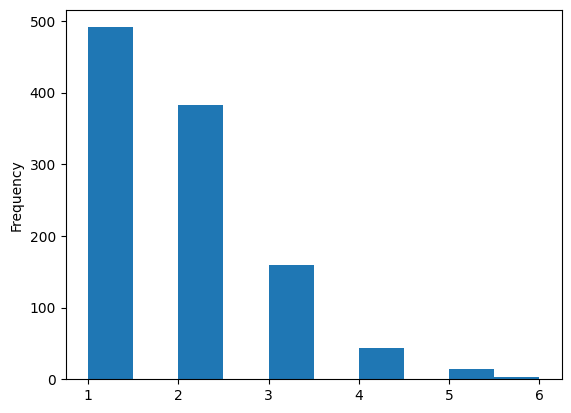

In [6]:
df['battery_power'].value_counts().plot(kind='hist')

In [7]:
bins = [500, 800, 1200, 1600, 1998]
group_names = ['gruppo1', 'gruppo2', 'gruppo3', 'gruppo4']

df['battery_power_cut'] = pd.cut(df['battery_power'], bins, labels=group_names)
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range,battery_power_cut
0,842,0,2.2,0,1,0,7,0.6,188,2,...,756,2549,9,7,19,0,0,1,1,gruppo2
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,1988,2631,17,3,7,1,1,0,2,gruppo2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1716,2603,11,2,9,1,1,0,2,gruppo1
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1786,2769,16,8,11,1,0,0,2,gruppo1
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1212,1411,8,2,15,1,1,0,1,gruppo4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1890,668,13,4,19,1,1,0,0,gruppo1
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,1965,2032,11,10,16,1,1,1,2,gruppo4
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,1632,3057,9,1,5,1,1,0,3,gruppo4
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,670,869,18,10,19,1,1,1,0,gruppo3


In [8]:
df['battery_power_cut'].value_counts()

battery_power_cut
gruppo2    545
gruppo4    519
gruppo3    514
gruppo1    422
Name: count, dtype: int64

In [9]:
df[['battery_power_cut', 'price_range']].value_counts()

battery_power_cut  price_range
gruppo4            3              177
gruppo2            0              167
gruppo3            3              151
gruppo2            1              142
gruppo1            0              137
gruppo4            2              135
gruppo3            1              127
gruppo4            1              124
gruppo3            2              123
gruppo2            2              122
gruppo1            2              120
gruppo2            3              114
gruppo3            0              113
gruppo1            1              107
gruppo4            0               83
gruppo1            3               58
Name: count, dtype: int64

## Es. 3

In [10]:
filtered_df = df[(df['four_g'] == 1) & (df['ram'] > 2048)]
filtered_df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range,battery_power_cut
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,1988,2631,17,3,7,1,1,0,2,gruppo2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1716,2603,11,2,9,1,1,0,2,gruppo1
6,1821,0,1.7,0,4,1,10,0.8,139,8,...,1018,3220,13,8,18,1,0,1,3,gruppo4
11,1520,1,2.2,0,5,1,33,0.5,177,8,...,1005,3826,14,9,13,1,1,1,3,gruppo3
16,838,0,0.5,0,1,1,13,0.1,196,8,...,1850,3554,10,9,19,1,0,1,3,gruppo2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1974,915,1,0.5,1,9,1,33,0.3,199,2,...,986,2156,7,3,13,1,1,0,1,gruppo2
1977,1379,0,1.1,1,1,1,18,0.2,129,2,...,885,2358,10,5,15,1,1,0,2,gruppo3
1991,1882,0,2.0,0,11,1,44,0.8,113,8,...,743,3579,19,8,20,1,1,0,3,gruppo4
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,1632,3057,9,1,5,1,1,0,3,gruppo4


Text(0, 0.5, 'int_memory')

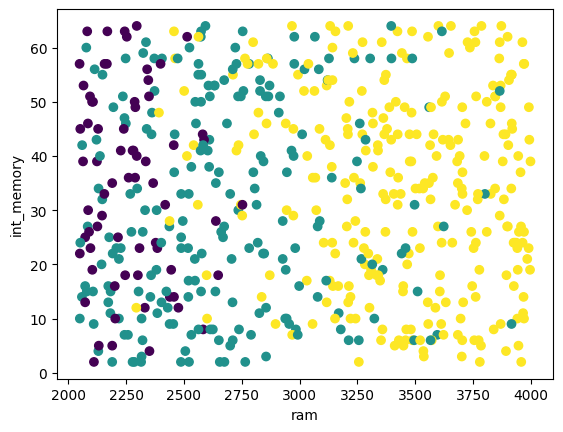

In [11]:
colours = filtered_df['price_range']

plt.scatter(filtered_df['ram'], filtered_df['int_memory'], c=colours)
plt.xlabel(filtered_df['ram'].name)
plt.ylabel(filtered_df['int_memory'].name)

## Es. 4

In [12]:
df['int_memory_cut'] = pd.cut(df['int_memory'], 5)

In [13]:
df.pivot_table('price_range', index=['touch_screen', 'int_memory_cut'], aggfunc='count')

/var/folders/ph/t7gwl3k17_l0cxktc3ll17600000gn/T/ipykernel_97789/1794368438.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table('price_range', index=['touch_screen', 'int_memory_cut'], aggfunc='count')


price_range
touch_screen int_memory_cut             
0            (1.938, 14.4]           210
             (14.4, 26.8]            192
             (26.8, 39.2]            208
             (39.2, 51.6]            185
             (51.6, 64.0]            199
1            (1.938, 14.4]           244
             (14.4, 26.8]            184
             (26.8, 39.2]            193
             (39.2, 51.6]            201
             (51.6, 64.0]            184

# Trasformazione e Predizione

## Es. 1
Si vuole predire il valore di range di prezzo sulla base degli attributi presenti nel dataset.
Ricaricare il dataset originale, eliminare eventuali attributi inutili (giustificare la scelta),
eliminare le eventuali istanze che contengono valori nulli, e dividere il dataset in modo che 3/4
degli elementi siano contenuti in un nuovo dataset “train” e 1/4 nel dataset “test” preservando
le proporzioni delle classi nella colonna target.

Allenare il train con il modello DecisionTree e valutare l’accuracy ottenuta calcolata sia sul
dataset train sia sul dataset test. Confrontare i risultati ottenuti con quelli ottenuti con una
predizione basata sul modello KNeighborsClassifier. Effettuare alcune considerazioni sui risultati
ottenuti, tenendo in considerazione anche l’analisi della confusion matrix e la predizione
effettuata da un dummy classifier a scelta. (punti 4)

In [14]:
df = pd.read_csv('dataset.csv', sep=',')
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [15]:
df = df.dropna()

In [16]:
X = df.drop(['price_range'], axis=1)
y = df['price_range']
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

Accuracy train: 1.0
Accuracy test: 0.828


<Axes: >

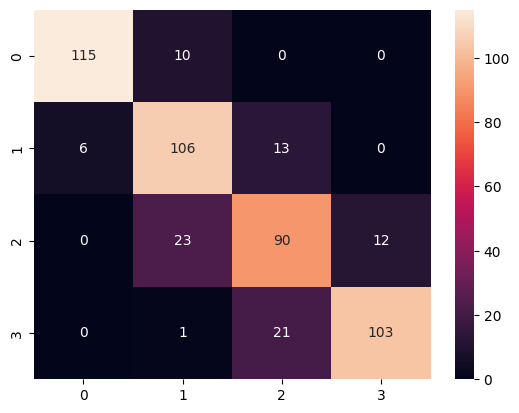

In [17]:
treeclf = tree.DecisionTreeClassifier(random_state=0)
treeclf.fit(X_train, y_train)
y_train_pred = treeclf.predict(X_train)
y_test_pred = treeclf.predict(X_test)
acc_tree_test = metrics.accuracy_score(y_test, y_test_pred)
print("Accuracy train:", metrics.accuracy_score(y_train, y_train_pred))
print("Accuracy test:", acc_tree_test)
cnf_matrix = metrics.confusion_matrix(y_test, y_test_pred)
sns.heatmap(cnf_matrix,annot=True,fmt="d")

Accuracy train: 0.9473333333333334
Accuracy test: 0.908


<Axes: >

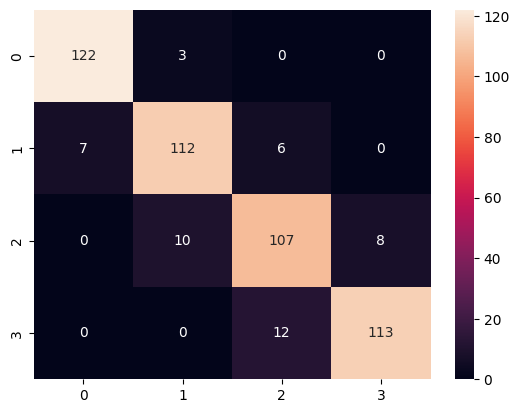

In [18]:
kneighbor = neighbors.KNeighborsClassifier()
kneighbor.fit(X_train, y_train)
y_train_pred = kneighbor.predict(X_train)
y_test_pred = kneighbor.predict(X_test)
print("Accuracy train:", metrics.accuracy_score(y_train, y_train_pred))
print("Accuracy test:", metrics.accuracy_score(y_test, y_test_pred))
cnf_matrix = metrics.confusion_matrix(y_test, y_test_pred)
sns.heatmap(cnf_matrix,annot=True,fmt="d")

Accuracy train: 0.26466666666666666
Accuracy test: 0.27


<Axes: >

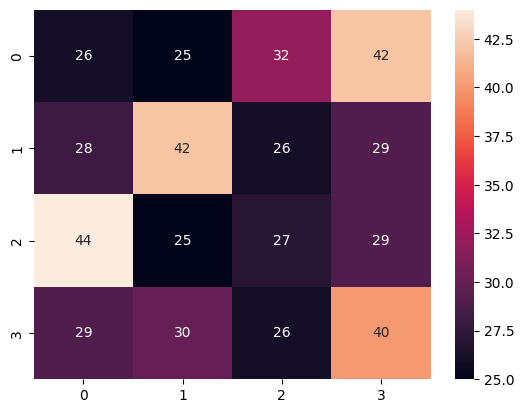

In [19]:
dummyclf = dummy.DummyClassifier(strategy='uniform', random_state=0)
dummyclf.fit(X_train, y_train)
y_train_pred = dummyclf.predict(X_train)
y_test_pred = dummyclf.predict(X_test)
print("Accuracy train:", metrics.accuracy_score(y_train, y_train_pred))
print("Accuracy test:", metrics.accuracy_score(y_test, y_test_pred))
cnf_matrix = metrics.confusion_matrix(y_test, y_test_pred)
sns.heatmap(cnf_matrix,annot=True,fmt="d")

## Es. 2
Confrontare l’accuratezza ottenuta nel punto precedente con l’accuratezza che si ottiene con
una 10 Fold cross validation. (punti 1)

In [20]:
scores = model_selection.cross_val_score(treeclf, X, y, scoring='accuracy', n_jobs=-1)
print(f'Accuracy: {scores.mean()*100}%')

Accuracy: 82.35%


## Es. 3
Trovare i parametri migliori del classificatore DecisionTree. Agire sui parametri criterion e
min_samples_leaf. Verificare se l’accuratezza che si ottiene con la nuova configurazione supera
quella ottenuta con i parametri di default al punto 1. (punti 3)

In [21]:
parameters = {'criterion': ["gini", "entropy", "log_loss"],
              'min_samples_leaf': [1, 3, 5, 10]}
model = tree.DecisionTreeClassifier()

gridsearch = model_selection.GridSearchCV(estimator=model, param_grid=parameters, scoring='accuracy')
gridsearch.fit(X_train, y_train)

print('Best params:', gridsearch.best_params_)
print('Best estimator:', gridsearch.best_estimator_)
print('Best score (accuracy):', gridsearch.best_score_)

y_pred = gridsearch.predict(X_test)
print(f'Accuracy: {metrics.accuracy_score(y_test, y_pred)}%')

Best params: {'criterion': 'entropy', 'min_samples_leaf': 10}
Best estimator: DecisionTreeClassifier(criterion='entropy', min_samples_leaf=10)
Best score (accuracy): 0.8446666666666667
Accuracy: 0.84%


## Es. 4
Studiare la correlazione tra tutte le feature del dataset, creare un dataframe che contiene,
oltre alla colonna target, le 5 feature più correlate (positivamente) al target. Ripetere la
classificazione sul nuovo dataset e verificare se l’accuratezza ottenuta con DecisionTree e
KNeighborsClassifier migliora (punti 3).

In [22]:
correlation_matrix = df.corr()
correlation_matrix

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
battery_power,1.000000,0.011252,0.011482,-0.041847,0.033334,0.015665,-0.004004,0.034085,0.001844,-0.029727,...,0.014901,-0.008402,-0.000653,-0.029959,-0.021421,0.052510,0.011522,-0.010516,-0.008343,0.200723
blue,0.011252,1.000000,0.021419,0.035198,0.003593,0.013443,0.041177,0.004049,-0.008605,0.036161,...,-0.006872,-0.041533,0.026351,-0.002952,0.000613,0.013934,-0.030236,0.010061,-0.021863,0.020573
clock_speed,0.011482,0.021419,1.000000,-0.001315,-0.000434,-0.043073,0.006545,-0.014364,0.012350,-0.005724,...,-0.014523,-0.009476,0.003443,-0.029078,-0.007378,-0.011432,-0.046433,0.019756,-0.024471,-0.006606
dual_sim,-0.041847,0.035198,-0.001315,1.000000,-0.029123,0.003187,-0.015679,-0.022142,-0.008979,-0.024658,...,-0.020875,0.014291,0.041072,-0.011949,-0.016666,-0.039404,-0.014008,-0.017117,0.022740,0.017444
fc,0.033334,0.003593,-0.000434,-0.029123,1.000000,-0.016560,-0.029133,-0.001791,0.023618,-0.013356,...,-0.009990,-0.005176,0.015099,-0.011014,-0.012373,-0.006829,0.001793,-0.014828,0.020085,0.021998
four_g,0.015665,0.013443,-0.043073,0.003187,-0.016560,1.000000,0.008690,-0.001823,-0.016537,-0.029706,...,-0.019236,0.007448,0.007313,0.027166,0.037005,-0.046628,0.584246,0.016758,-0.017620,0.014772
int_memory,-0.004004,0.041177,0.006545,-0.015679,-0.029133,0.008690,1.000000,0.006886,-0.034214,-0.028310,...,0.010441,-0.008335,0.032813,0.037771,0.011731,-0.002790,-0.009366,-0.026999,0.006993,0.044435
m_dep,0.034085,0.004049,-0.014364,-0.022142,-0.001791,-0.001823,0.006886,1.000000,0.021756,-0.003504,...,0.025263,0.023566,-0.009434,-0.025348,-0.018388,0.017003,-0.012065,-0.002638,-0.028353,0.000853
mobile_wt,0.001844,-0.008605,0.012350,-0.008979,0.023618,-0.016537,-0.034214,0.021756,1.000000,-0.018989,...,0.000939,0.000090,-0.002581,-0.033855,-0.020761,0.006209,0.001551,-0.014368,-0.000409,-0.030302
n_cores,-0.029727,0.036161,-0.005724,-0.024658,-0.013356,-0.029706,-0.028310,-0.003504,-0.018989,1.000000,...,-0.006872,0.024480,0.004868,-0.000315,0.025826,0.013148,-0.014733,0.023774,-0.009964,0.004399


In [23]:
corr_to_target = correlation_matrix['price_range'].sort_values(ascending=False)
top_5_corr_features = corr_to_target.iloc[1:6].index.tolist()
top_5_corr_features

['ram', 'battery_power', 'px_width', 'px_height', 'int_memory']

In [24]:
new_df = df[[*top_5_corr_features, 'price_range']]
new_df

,ram,battery_power,px_width,px_height,int_memory,price_range
0,2549,842,756,20,7,1
1,2631,1021,1988,905,53,2
2,2603,563,1716,1263,41,2
3,2769,615,1786,1216,10,2
4,1411,1821,1212,1208,44,1
...,...,...,...,...,...,...
1995,668,794,1890,1222,2,0
1996,2032,1965,1965,915,39,2
1997,3057,1911,1632,868,36,3
1998,869,1512,670,336,46,0


In [25]:
X = new_df.drop(['price_range'], axis=1)
y = new_df['price_range']
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

In [26]:
treeclf.fit(X_train, y_train)
y_train_pred = treeclf.predict(X_train)
y_test_pred = treeclf.predict(X_test)
print("Accuracy train:", metrics.accuracy_score(y_train, y_train_pred))
print("Accuracy test:", metrics.accuracy_score(y_test, y_test_pred))

Accuracy train: 1.0
Accuracy test: 0.844


In [27]:
kneighbor.fit(X_train, y_train)
y_train_pred = kneighbor.predict(X_train)
y_test_pred = kneighbor.predict(X_test)
print("Accuracy train:", metrics.accuracy_score(y_train, y_train_pred))
print("Accuracy test:", metrics.accuracy_score(y_test, y_test_pred))

Accuracy train: 0.946
Accuracy test: 0.91


## Es. 5
Creare una pipeline in cui gli attributi int_memory, ram e talk_time sono scalati in
modo che abbiano media 0 e varianza 1, gli attributi mobile_wt e battery_power sono
discretizzati in 5 intervalli, e tutti gli altri attributi sono lasciati invariati. La pipeline deve
applicare il modello DecisionTree con i parametri migliori trovati al punto 2. Valutare
l’accuratezza della classificazione. (punti 3)

In [28]:
df = pd.read_csv('dataset.csv', sep=',')
X = df.drop(['price_range'], axis=1)
y = df['price_range']
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

In [29]:
gridsearch.best_params_

{'criterion': 'entropy', 'min_samples_leaf': 10}

In [30]:
to_scale = ['int_memory', 'ram', 'talk_time']
to_discr = ['mobile_wt', 'battery_power']

preprocessor = compose.ColumnTransformer(transformers=[
    ('scale', preprocessing.StandardScaler(), to_scale),
    ('discr', preprocessing.KBinsDiscretizer(n_bins=5), to_discr),
], remainder='passthrough')

model = tree.DecisionTreeClassifier(**gridsearch.best_params_)

my_pipeline = pipeline.Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

my_pipeline.fit(X_train, y_train)
y_train_pred = my_pipeline.predict(X_train)
y_test_pred = my_pipeline.predict(X_test)

print("Accuracy train:", metrics.accuracy_score(y_train, y_train_pred))
print("Accuracy test:", metrics.accuracy_score(y_test, y_test_pred))

Accuracy train: 0.9066666666666666
Accuracy test: 0.812


## Es. 6
Aggiungere alla pipeline del punto 5 la funzione SelectKBest
(https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html
?highlight=selectkbest#sklearn.feature_selection.SelectKBest). Utilizzare la funzione di
gridSearchCV per selezionare il K migliore e anche il numero migliore di bin in cui discretizzare i
valori di mobile_wt e battery_power (scegliere a piacere alcuni valori) (punti 3).

In [31]:
my_pipeline2 = pipeline.Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selection', feature_selection.SelectKBest()),
    ('model', model)
])

parameters = {
    'preprocessor__discr__n_bins': [3, 5, 7],
    'selection__k': [2, 3, 4, 5],
}

gridsearch = model_selection.GridSearchCV(my_pipeline2, parameters, scoring='accuracy', cv=5, n_jobs=-1)
gridsearch.fit(X_train, y_train)
print('Best params:', gridsearch.best_params_)
print('Best estimator:', gridsearch.best_estimator_)
print('Best score:', gridsearch.best_score_)

y_pred = gridsearch.predict(X_test)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("F1 Score:", metrics.f1_score(y_test, y_pred, average='weighted'))

Best params: {'preprocessor__discr__n_bins': 3, 'selection__k': 5}
Best estimator: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scale', StandardScaler(),
                                                  ['int_memory', 'ram',
                                                   'talk_time']),
                                                 ('discr',
                                                  KBinsDiscretizer(n_bins=3),
                                                  ['mobile_wt',
                                                   'battery_power'])])),
                ('selection', SelectKBest(k=5)),
                ('model',
                 DecisionTreeClassifier(criterion='entropy',
                                        min_samples_leaf=10))])
Best score: 0.8446666666666666
Accuracy: 0.866
F1 Score: 0.8662955664493349


## Es. 7
Creare una nuova pipeline che applica la decomposizione TruncatedSVD (simile alla PCA -
https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html)
al dataset iniziale e aggiunge le componenti ottenute alla pipeline del punto 5. Valutare il valore
migliore per il numero di componenti di TruncatedSVD tra 2, 4 e 6. (punti 3).

In [32]:
trunc = decomposition.TruncatedSVD()
combined_features = pipeline.FeatureUnion([('preprocessor', preprocessor), ('trunc', trunc)])

X_train_features = combined_features.fit(X_train, y_train).transform(X_train)
print("Combined space has", X_train_features.shape[1], "features")

Combined space has 30 features


In [33]:
my_pipeline3 = pipeline.Pipeline(steps=[
    ('combined_features', combined_features),
    ('model', model),
])
my_pipeline3

/opt/anaconda3/envs/BDTA/lib/python3.13/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('combined_features',
                 FeatureUnion(transformer_list=[('preprocessor',
                                                 ColumnTransformer(remainder='passthrough',
                                                                   transformers=[('scale',
                                                                                  StandardScaler(),
                                                                                  ['int_memory',
                                                                                   'ram',
                                                                                   'talk_time']),
                                                                                 ('discr',
                                                                                  KBinsDiscretizer(),
                                                                                  ['mobile_wt',
                                                                                   'battery_power'])])),
                                                ('trunc', TruncatedSVD())])),
                ('model',
                 DecisionTreeClassifier(criterion='entropy',
                                        min_samples_leaf=10))])

In [34]:
parameters = {
    'combined_features__trunc__n_components' : [2, 4, 6]
}

gridsearch = model_selection.GridSearchCV(my_pipeline3, parameters, scoring='accuracy')
gridsearch.fit(X_train, y_train)
print('Best params:', gridsearch.best_params_)
print('Best estimator:', gridsearch.best_estimator_)
print('Best score:', gridsearch.best_score_)

y_pred = gridsearch.predict(X_test)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("F1 Score:", metrics.f1_score(y_test, y_pred, average='weighted'))

Best params: {'combined_features__trunc__n_components': 6}
Best estimator: Pipeline(steps=[('combined_features',
                 FeatureUnion(transformer_list=[('preprocessor',
                                                 ColumnTransformer(remainder='passthrough',
                                                                   transformers=[('scale',
                                                                                  StandardScaler(),
                                                                                  ['int_memory',
                                                                                   'ram',
                                                                                   'talk_time']),
                                                                                 ('discr',
                                                                                  KBinsDiscretizer(),
                                                             